# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [51]:
# Import the library
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from PIL import ImageOps
from skimage import data

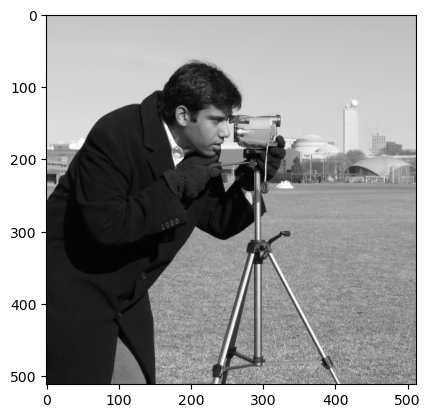

In [20]:
# ── Load image ────────────────────────────────────
image1 = Image.fromarray(data.camera())
plt.imshow(image1 , cmap = 'gray')

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [22]:
# Get the size of the image
width, height = image1.size

# scaling factors
scale_x = 2
scale_y = 2

In [ ]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

image1_scaled = image1.resize((width * scale_x, height * scale_y), Image.Resampling.LANCZOS)


New Size:  (1024, 1024)


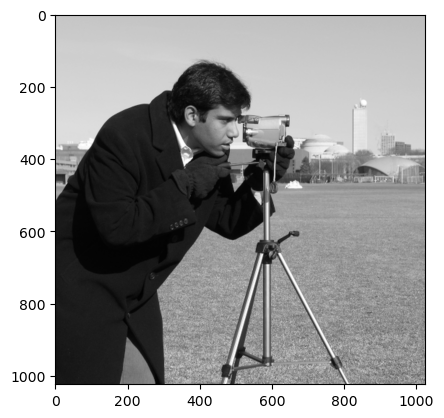

In [30]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
plt.imshow(image1_scaled , cmap ='gray')
image1_scaled.save("task1_1_scaled.jpg")
print("New Size: ", image1_scaled.size)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [26]:
scale2_x = 2
scale2_y = 1

In [27]:
image1_scaled2 = image1.resize((width * scale2_x, height * scale2_y), Image.Resampling.LANCZOS)

New Size:  (1024, 512)


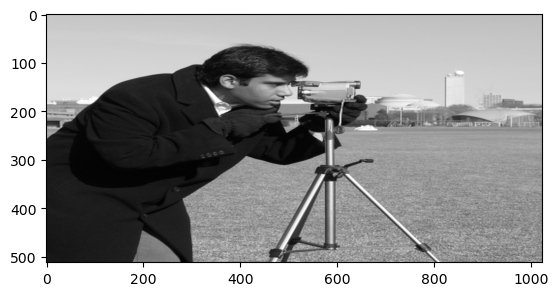

In [31]:
plt.imshow(image1_scaled2 , cmap = 'gray')
image1_scaled.save("task1_1_horizontally_stretch.jpg")
print("New Size: ", image1_scaled2.size)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

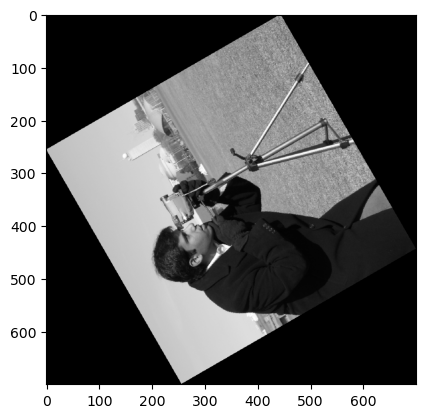

In [33]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
image1_rotate120 = image1.rotate(120, expand=True)
plt.imshow(image1_rotate120, cmap='gray')
image1_rotate120.save("task1_2_rotated.jpg")


### 3. Shear

In [35]:
# -- c. Get the image dimensions ────────────────────
print(image1.size)

(512, 512)


In [36]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = np.array([ #X-axis
    [1, shear_factor],
    [0, 1]
])
print(shear_matrix)

[[1.  0.5]
 [0.  1. ]]


In [40]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shx = shear_factor
shy = 0
inverse_matrix = (1, shx, 0,
                  shy, 1, 0)

sheared_image = image1.transform(
    image1.size,
    Image.Transform.AFFINE,
    inverse_matrix
)

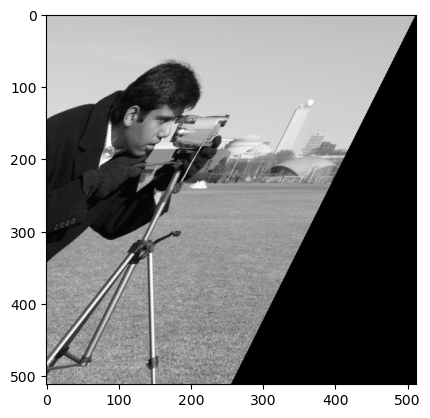

In [42]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
plt.imshow(sheared_image , cmap ='gray')
sheared_image.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

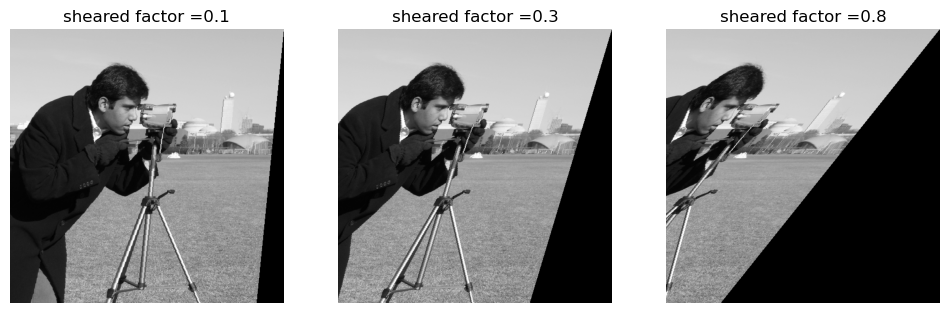

In [48]:
shear_factor2 = 0.1
shear_matrix2 = np.array([ #X-axis
    [1, shear_factor2],
    [0, 1]
])


shx2 = shear_factor2
shy2 = 0
inverse_matrix2 = (1, shx2, 0,
                  shy2, 1, 0)

sheared_image2 = image1.transform(
    image1.size,
    Image.Transform.AFFINE,
    inverse_matrix2
)



shear_factor3 = 0.3
shear_matrix3 = np.array([ #X-axis
    [1, shear_factor3],
    [0, 1]
])

shx3 = shear_factor3
shy3 = 0
inverse_matrix3 = (1, shx3, 0,
                  shy3, 1, 0)

sheared_image3 = image1.transform(
    image1.size,
    Image.Transform.AFFINE,
    inverse_matrix3
)


shear_factor4 = 0.8
shear_matrix4 = np.array([ #X-axis
    [1, shear_factor4],
    [0, 1]
])

shx4 = shear_factor4
shy4 = 0
inverse_matrix4 = (1, shx4, 0,
                  shy4, 1, 0)

sheared_image4 = image1.transform(
    image1.size,
    Image.Transform.AFFINE,
    inverse_matrix4
)


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(sheared_image2, cmap='gray')
plt.title('sheared factor =0.1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(sheared_image3, cmap='gray')
plt.title('sheared factor =0.3'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(sheared_image4, cmap='gray')
plt.title('sheared factor =0.8'), plt.axis('off')
plt.show()


# Intensity Transformations
Negative · Log · Power Law (Gamma)

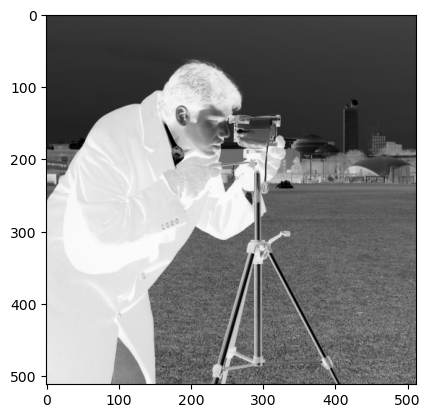

In [49]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(image1)
negative = 255 - img_array
negative_img = Image.fromarray(negative.astype(np.uint8))
plt.imshow(negative_img, cmap='gray')


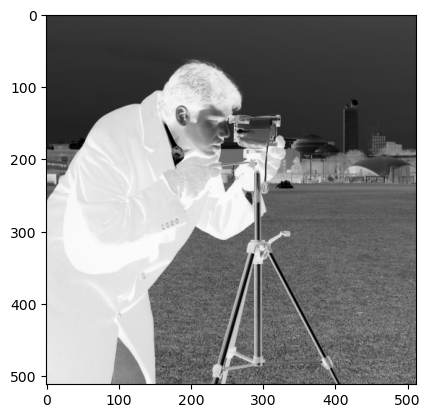

In [ ]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(image1)
plt.imshow(negative_img2, cmap='gray')

C:\Users\z-hay\AppData\Local\Temp\ipykernel_43164\1939064039.py:13: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + np.array(image1))
C:\Users\z-hay\AppData\Local\Temp\ipykernel_43164\1939064039.py:14: RuntimeWarning: invalid value encountered in cast
  log_img = np.uint8(log_img)


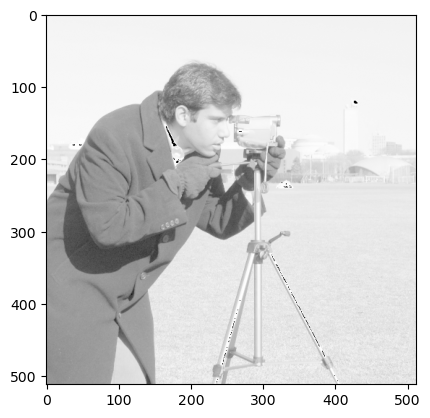

In [ ]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)




# Apply the log transformation to each pixel
log_img = c * np.log(1 + np.array(image1))
log_img = np.uint8(log_img)
plt.imshow(log_img, cmap='gray')

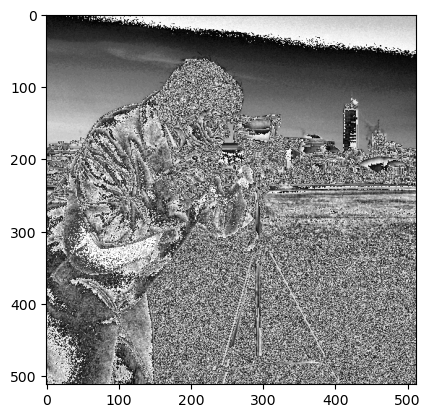

In [54]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
gamma_img = np.power(img_array, gamma)
gamma_img = np.uint8(gamma_img * 255)
plt.imshow(gamma_img, cmap='gray')

